<a href="https://colab.research.google.com/github/alfajrii/retail-sales-analysis-python/blob/main/Retail_Sales_Analysis_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Tugas Hari 2: Laporan buat Calon Investor

Teh Rina masih butuh beberapa insight tambahan buat pertemuan investornya. Kerjakan 5 soal di bawah ini pakai data yang sama kayak di kelas tadi (`transaksi_operasional_rempah.csv` dan `master_produk_rempah_bandung.csv`).

**Petunjuk pengerjaan:**

- Isi kode kamu di cell kode yang sudah disediakan di bawah tiap soal, tepat di bawah komentar instruksi.
- Boleh nambah cell baru sendiri kalau butuh cek data dulu sebelum jawab.
- Jangan lupa jalankan cell setup di bawah dulu (upload data + merge) sebelum ngerjain soal-soal.

**Daftar soal:**

| No | Soal | Tingkat Kesulitan |
|---|---|---|
| 1 | Merge data & verifikasi hasilnya | Gampang |
| 2 | Distribusi jarak antar (distance_km) | Gampang |
| 3 | Tabel ringkasan jumlah transaksi (order_type x status) | Gampang |
| 4 | Persentase transaksi tanpa diskon | Sedang |
| 5 | Kategori dengan selisih pendapatan terbesar antar cara pesan | Agak Sulit |

---

## Setup (jalankan dulu sebelum mulai ngerjain)


In [ ]:
from google.colab import files

print("Silakan upload transaksi_operasional_rempah.csv dan master_produk_rempah_bandung.csv sekaligus")
uploaded = files.upload()


Silakan upload transaksi_operasional_rempah.csv dan master_produk_rempah_bandung.csv sekaligus


Saving master_produk_rempah_bandung.csv to master_produk_rempah_bandung.csv
Saving transaksi_operasional_rempah.csv to transaksi_operasional_rempah (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

transaksi = pd.read_csv("transaksi_operasional_rempah.csv")
master_produk = pd.read_csv("master_produk_rempah_bandung.csv")

print("transaksi:", transaksi.shape)
print("master_produk:", master_produk.shape)


transaksi: (10000, 13)
master_produk: (100, 4)


---
## Soal 1: Merge Data & Verifikasi Hasilnya

1. Gabungkan `transaksi` dan `master_produk` berdasarkan `product_name`, simpan hasilnya ke variabel `df`.
2. Ubah kolom `sales_date` jadi tipe data `datetime`.
3. Verifikasi: cek apakah ada baris di `df` yang kolom `category`-nya kosong setelah merge (kalau ada, berarti ada produk yang nggak ketemu pasangannya).


In [ ]:
# 1. Merge transaksi dan master_produk berdasarkan product_name, simpan ke df


# 2. Ubah kolom sales_date jadi tipe data datetime


# 3. Cek apakah ada category yang kosong setelah merge



In [ ]:
# 1. Merge transaksi dan master_produk berdasarkan product_name, simpan ke df
df = transaksi.merge(
    master_produk,
    on="product_name",
    how="left"
)

# 2. Ubah kolom sales_date jadi tipe data datetime
df["sales_date"] = pd.to_datetime(df["sales_date"])

# 3. Cek apakah ada category yang kosong setelah merge
print("Jumlah category kosong:", df["category"].isna().sum())

print("Ukuran data setelah merge:", df.shape)
print("Jumlah category kosong:", df["category"].isna().sum())
transaksi.head()

Jumlah category kosong: 0
Ukuran data setelah merge: (10000, 16)
Jumlah category kosong: 0


,sales_date,order_id,customer_name,customer_address,product_name,quantity,order_type,distance_km,discount,total,shipping_fee,total_sales,status
0,2025-07-17,RMP00001,Customer_1198,"Kecamatan Cicalengka, Kabupaten Bandung",Bunga Lawang (Pekak),1,Beli di Toko,0.0,0.0,9000,0,9000,completed
1,2025-09-11,RMP00002,Customer_3969,"Kecamatan Gedebage, Kota Bandung",Kencur,1,Beli di Toko,0.0,0.0,8000,0,8000,completed
2,2025-11-15,RMP00003,Customer_575,"Kecamatan Padalarang, Kabupaten Bandung Barat",Paket Bumbu Gule Sapi,2,Diantar (Aplikasi Toko),14.2,0.0,30000,25000,55000,completed
3,2025-06-06,RMP00004,Customer_1394,"Kecamatan Cisarua, Kabupaten Bandung Barat",Paket Bumbu Soto Betawi,1,Beli di Toko,0.0,0.0,22000,0,22000,completed
4,2025-12-13,RMP00005,Customer_1382,"Kecamatan Sukajadi, Kota Bandung",Paket Bumbu Woku Manado,1,Diantar (Aplikasi Toko),1.5,0.0,20000,0,20000,completed


---
## Soal 2: Distribusi Jarak Antar

Buat histogram dari kolom `distance_km` (untuk semua transaksi, nggak perlu difilter status). Dari bentuk histogramnya, kira-kira lebih banyak pelanggan yang jaraknya dekat atau jauh dari toko?

*Petunjuk: inget, `distance_km` bernilai 0 untuk transaksi "Beli di Toko".*


In [ ]:
# Buat histogram dari kolom distance_km



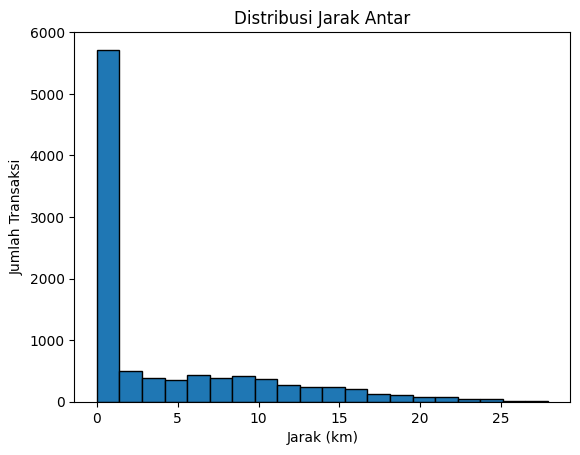

In [ ]:
# Pastikan distance_km berupa numerik
df["distance_km"] = pd.to_numeric(df["distance_km"], errors="coerce")

# Buat histogram dari kolom distance_km
plt.hist(df["distance_km"].dropna(), bins=20, edgecolor="black")

plt.title("Distribusi Jarak Antar")
plt.xlabel("Jarak (km)")
plt.ylabel("Jumlah Transaksi")
plt.show()

---
## Soal 3: Tabel Ringkasan Jumlah Transaksi

Buat tabel ringkasan (pakai `pivot_table`) yang menunjukkan **jumlah transaksi** (bukan pendapatan) untuk tiap kombinasi `order_type` dan `status`. Ini berguna buat lihat, misalnya, apakah transaksi yang dibatalkan (`cancelled`) lebih banyak terjadi di pesanan "Beli di Toko" atau "Diantar (Aplikasi Toko)".

*Petunjuk: pakai `aggfunc="count"` atau `aggfunc="size"`, dan kolom `values` bisa pakai `order_id`.*


In [ ]:
# Buat pivot_table jumlah transaksi (count) dengan index order_type dan columns status



In [ ]:
# Buat pivot_table jumlah transaksi berdasarkan order_type dan status
tabel_transaksi = pd.pivot_table(
    df,
    index="order_type",
    columns="status",
    values="order_id",
    aggfunc="count",
    fill_value=0
)

print(tabel_transaksi)
index="order_type"

status                   cancelled  completed  refund
order_type                                           
Beli di Toko                   329       4976     232
Diantar (Aplikasi Toko)        252       4033     178


---
## Soal 4: Persentase Transaksi Tanpa Diskon

Khusus untuk transaksi berstatus `"completed"`, berapa persen transaksi yang **tidak mendapat diskon sama sekali** (nilai `discount` = 0)? Tampilkan juga persentase untuk masing-masing besaran diskon yang ada.


In [ ]:
# Filter transaksi yang statusnya "completed"


# Hitung persentase (distribusi) nilai discount, dan cek berapa persen yang nilainya 0



In [ ]:
# Filter transaksi yang statusnya "completed"
df_completed = df[df["status"] == "completed"]

# Hitung persentase (distribusi) nilai discount
persentase_diskon = df_completed["discount"].value_counts(normalize=True) * 100

print(persentase_diskon)

discount
0.00    81.607282
0.05    11.155511
0.10     7.237207
Name: proportion, dtype: float64


---
## Soal 5: Kategori dengan Selisih Pendapatan Terbesar

Teh Rina penasaran, kategori produk mana yang polanya paling beda antara pelanggan yang beli langsung di toko vs yang pesan lewat aplikasi. Kerjakan langkah berikut:

1. Khusus transaksi `"completed"`, buat tabel ringkasan (`pivot_table`) total `total_sales` untuk tiap kombinasi `order_type` (baris) dan `category` (kolom).
2. Dari tabel itu, hitung **selisih absolut** pendapatan antara "Diantar (Aplikasi Toko)" dan "Beli di Toko" untuk masing-masing kategori.
3. Kategori mana yang selisihnya paling besar?
4. Buat bar chart (grouped bar chart) yang membandingkan pendapatan tiap kategori berdasarkan `order_type`, biar keliatan visualisasinya.

*Petunjuk untuk langkah 4: DataFrame hasil `pivot_table` bisa langsung dipanggil `.plot(kind="bar")`.*


In [ ]:
# 1. Buat pivot_table total_sales dengan index order_type dan columns category (khusus completed)


# 2. Hitung selisih absolut antara "Diantar (Aplikasi Toko)" dan "Beli di Toko" per kategori


# 3. Urutkan dan tampilkan kategori dengan selisih terbesar


# 4. Buat grouped bar chart dari pivot_table tersebut



category                 Paket Bumbu Instan  Rempah & Sayuran Segar  \
order_type                                                            
Beli di Toko                      126946100                16586750   
Diantar (Aplikasi Toko)           137974950                28571425   

category                 Rempah Kering & Bumbu Dapur  
order_type                                            
Beli di Toko                                18848175  
Diantar (Aplikasi Toko)                     28718900  

Selisih pendapatan:
category
Paket Bumbu Instan             11028850
Rempah & Sayuran Segar         11984675
Rempah Kering & Bumbu Dapur     9870725
dtype: int64

Urutan selisih terbesar:
category
Rempah & Sayuran Segar         11984675
Paket Bumbu Instan             11028850
Rempah Kering & Bumbu Dapur     9870725
dtype: int64

Kategori dengan selisih terbesar:
category
Rempah & Sayuran Segar    11984675
dtype: int64


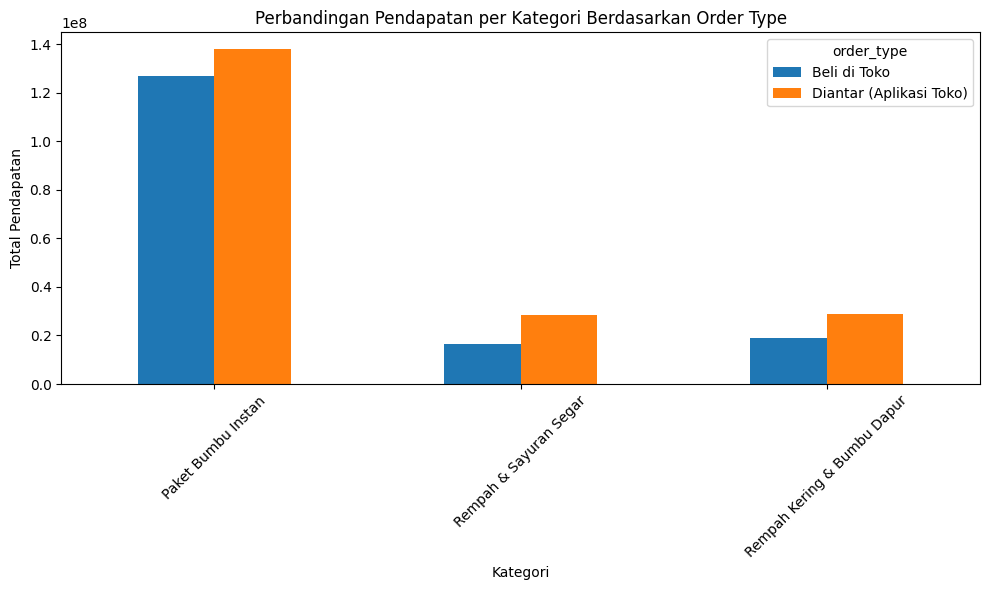

In [ ]:
# Khusus transaksi completed
df_completed = df[df["status"] == "completed"]

# 1. Buat pivot_table total_sales
pivot_pendapatan = pd.pivot_table(
    df_completed,
    index="order_type",
    columns="category",
    values="total_sales",
    aggfunc="sum",
    fill_value=0
)

print(pivot_pendapatan)


# 2. Hitung selisih absolut pendapatan per kategori
selisih = abs(
    pivot_pendapatan.loc["Diantar (Aplikasi Toko)"] -
    pivot_pendapatan.loc["Beli di Toko"]
)

print("\nSelisih pendapatan:")
print(selisih)


# 3. Urutkan dan tampilkan kategori dengan selisih terbesar
selisih_terbesar = selisih.sort_values(ascending=False)

print("\nUrutan selisih terbesar:")
print(selisih_terbesar)

print("\nKategori dengan selisih terbesar:")
print(selisih_terbesar.head(1))


# 4. Buat grouped bar chart
pivot_pendapatan.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Pendapatan per Kategori Berdasarkan Order Type")
plt.xlabel("Kategori")
plt.ylabel("Total Pendapatan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Selesai!

Mantap, laporan buat Teh Rina makin lengkap. Jangan lupa rangkum semua temuan dari tugas ini jadi bagian dari portofolio kamu ya! 🌶️📊
